#Bivariate Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/python/Project/EDA on Customer Churn/telecom_customer_churn.csv")

In [ ]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


<Axes: xlabel='Customer Status', ylabel='Monthly Charge'>

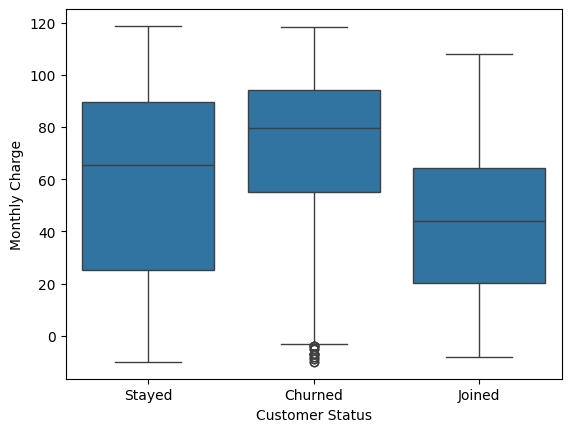

In [ ]:
sns.boxplot(data=df, x="Customer Status", y="Monthly Charge")

<Axes: xlabel='Customer Status', ylabel='Total Charges'>

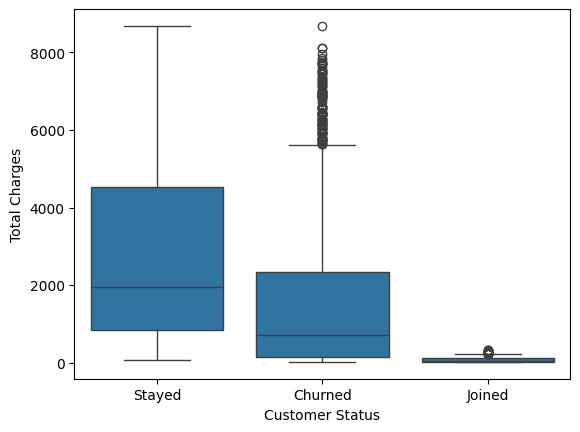

In [ ]:
sns.boxplot(data=df, x="Customer Status", y="Total Charges")

<Axes: xlabel='Customer Status', ylabel='Tenure in Months'>

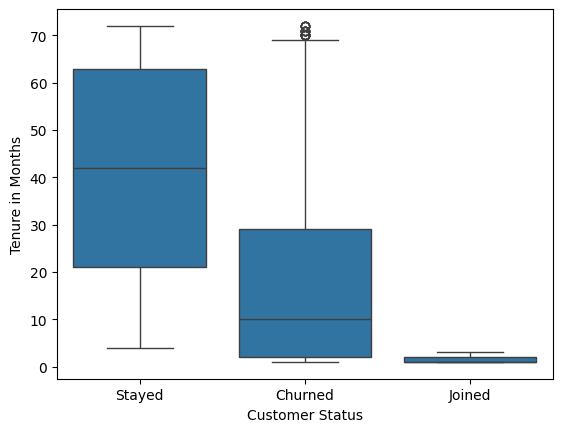

In [ ]:
sns.boxplot(data=df, x="Customer Status", y="Tenure in Months")

<Axes: xlabel='Internet Service', ylabel='count'>

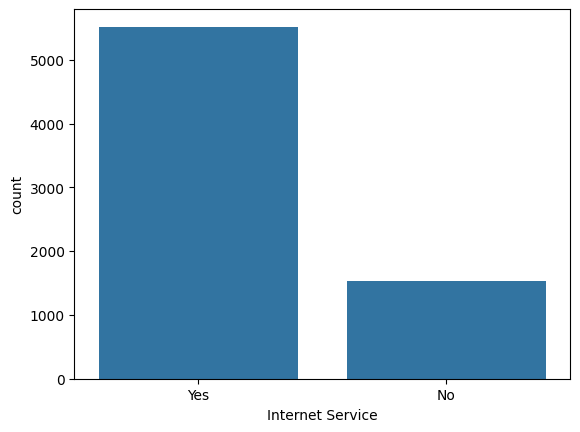

In [ ]:
sns.countplot(data=df, x="Internet Service")

<Axes: xlabel='Monthly Charge', ylabel='Total Revenue'>

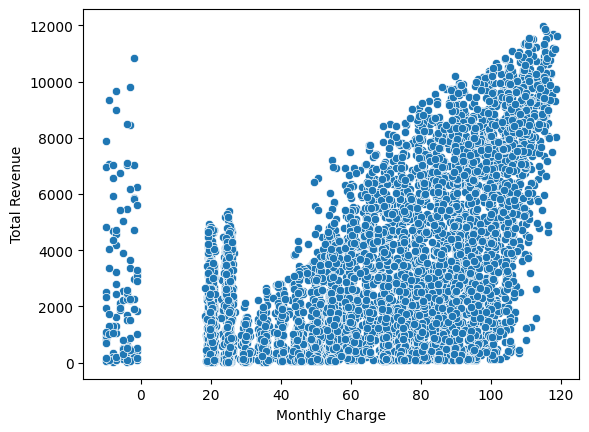

In [ ]:
sns.scatterplot(data=df, x="Monthly Charge", y="Total Revenue")

In [ ]:
sns.barplot(data=df, x="")

In [ ]:
df['Customer Status'].value_counts()['Churned']

np.int64(1869)

In [ ]:
df.groupby('Internet Service')['Customer Status'].value_counts()

Internet Service  Customer Status
No                Stayed             1231
                  Joined              182
                  Churned             113
Yes               Stayed             3489
                  Churned            1756
                  Joined              272
Name: count, dtype: int64

In [ ]:
###
df.groupby('Customer Status')['Tenure in Months'].mean()

,Tenure in Months
Customer Status,
Churned,17.979133
Joined,1.720264
Stayed,41.041525


In [ ]:
#what is the average revenue for each churn category
df.groupby('Customer Status')['Total Revenue'].mean()

,Total Revenue
Customer Status,
Churned,1971.353569
Joined,119.558921
Stayed,3735.676297


In [ ]:
df.groupby('Churn Category')['Total Revenue'].mean()

,Total Revenue
Churn Category,
Attitude,1845.713790
Competitor,2014.759988
Dissatisfaction,1925.169034
Other,1947.193077
Price,2076.417725


In [ ]:
df['Churn Category'].value_counts()

,count
Churn Category,
Competitor,841
Dissatisfaction,321
Attitude,314
Price,211
Other,182


In [ ]:
df[df['Customer Status'] == 'Churned']['Churn Reason'].value_counts()

,count
Churn Reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


In [ ]:
competitor_reason = df[(df['Customer Status'] == 'Churned') &
(df['Churn Category'] == "Competitor")]['Churn Reason'].value_counts()
print(competitor_reason)

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Competitor offered more data                 117
Competitor offered higher download speeds    100
Name: count, dtype: int64


In [ ]:
df.groupby('Churn Category')['Churn Reason'].value_counts()

Churn Category   Churn Reason                             
Attitude         Attitude of support person                   220
                 Attitude of service provider                  94
Competitor       Competitor had better devices                313
                 Competitor made better offer                 311
                 Competitor offered more data                 117
                 Competitor offered higher download speeds    100
Dissatisfaction  Product dissatisfaction                       77
                 Network reliability                           72
                 Service dissatisfaction                       63
                 Limited range of services                     37
                 Poor expertise of online support              31
                 Lack of self-service on Website               29
                 Poor expertise of phone support               12
Other            Don't know                                   130
                 Moved                                         46
                 Deceased                                       6
Price            Price too high                                78
                 Long distance charges                         64
                 Extra data charges                            39
                 Lack of affordable download/upload speed      30
Name: count, dtype: int64

In [ ]:
df.groupby('Churn Category')['Churn Reason'].count()

,Churn Reason
Churn Category,
Attitude,314
Competitor,841
Dissatisfaction,321
Other,182
Price,211


In [ ]:
Attitude_Category = df['Churn Category'].value_counts()['Attitude']
Competitor_Category = df['Churn Category'].value_counts()['Competitor']
Dissatisfaction_Category = df['Churn Category'].value_counts()['Dissatisfaction']
Other_Category = df['Churn Category'].value_counts()['Other']
Price_Category = df['Churn Category'].value_counts()['Price']


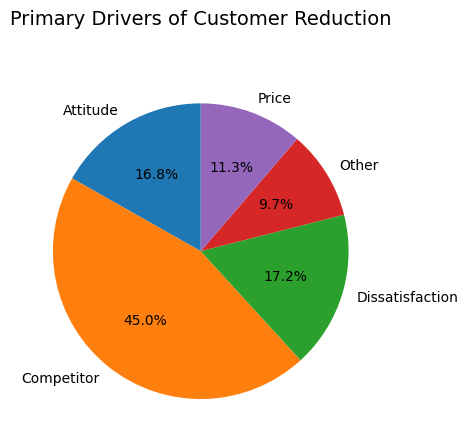

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
labels = 'Attitude', 'Competitor', 'Dissatisfaction', 'Other', 'Price'
sizes =  Attitude_Category, Competitor_Category, Dissatisfaction_Category, Other_Category, Price_Category

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Primary Drivers of Customer Reduction', loc='center', pad=30, fontsize=14)
plt.savefig("diagram1.png", dpi=300)
plt.show()
files.download('diagram1.png')

In [ ]:
df.groupby('Internet Type')['Customer Status'].value_counts()

Internet Type  Customer Status
Cable          Stayed              561
               Churned             213
               Joined               56
DSL            Stayed             1230
               Churned             307
               Joined              115
Fiber Optic    Stayed             1698
               Churned            1236
               Joined              101
Name: count, dtype: int64

<Axes: xlabel='Internet Type', ylabel='count'>

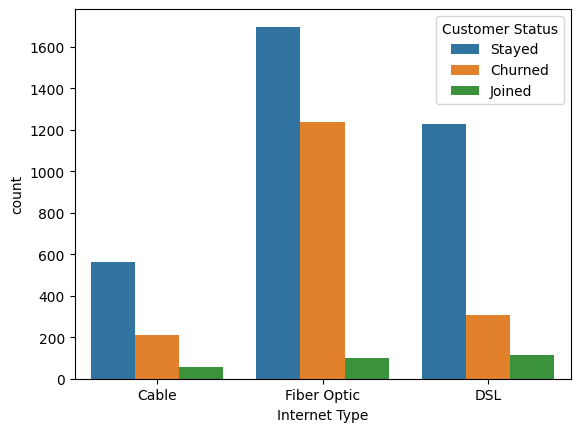

In [ ]:
sns.countplot(data=df, x='Internet Type', hue='Customer Status')

<Axes: xlabel='Married', ylabel='count'>

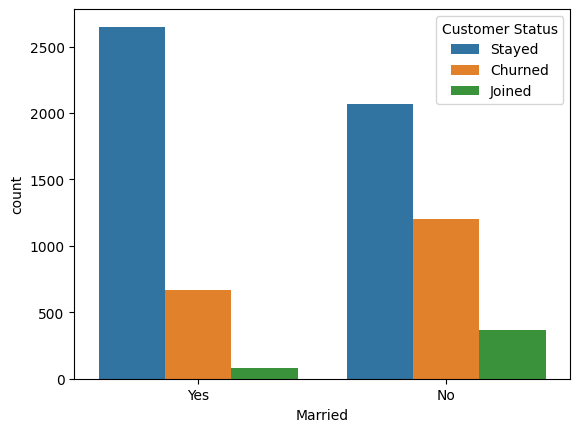

In [ ]:
sns.countplot(data=df, x='Married', hue='Customer Status')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

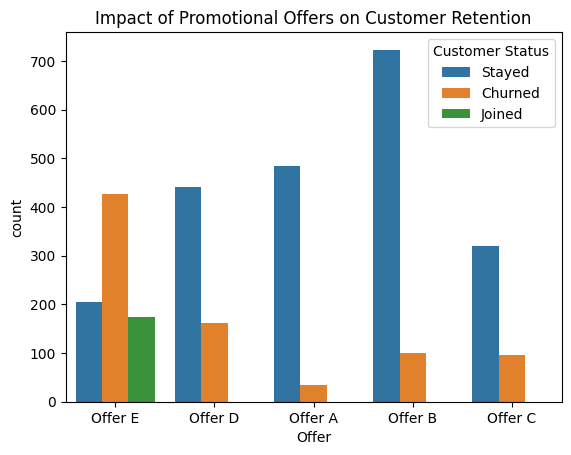

In [ ]:
from google.colab import files
sns.countplot(data=df, x='Offer', hue='Customer Status')
plt.title('Impact of Promotional Offers on Customer Retention')
plt.savefig("diagram2.png")
files.download("diagram2.png")

In [ ]:
df.groupby('Gender')['Customer Status'].value_counts()

Gender  Customer Status
Female  Stayed             2338
        Churned             939
        Joined              211
Male    Stayed             2382
        Churned             930
        Joined              243
Name: count, dtype: int64

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

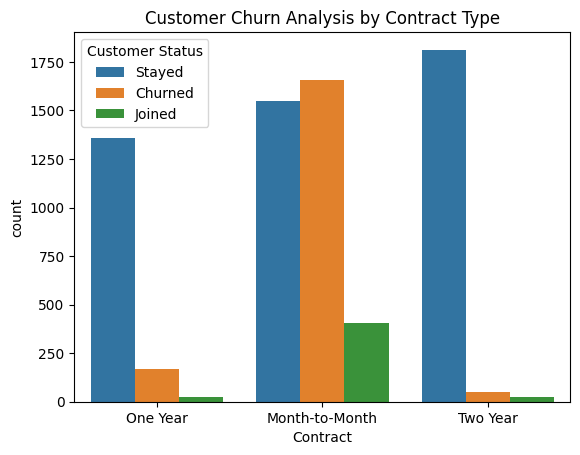

In [ ]:
from google.colab import files
sns.countplot(data=df, x='Contract', hue='Customer Status')
plt.title('Customer Churn Analysis by Contract Type')
plt.savefig("diagram3.png")
files.download("diagram3.png")

In [ ]:
df.groupby('Number of Dependents')['Customer Status'].value_counts()

Number of Dependents  Customer Status
0                     Stayed             3279
                      Churned            1763
                      Joined              374
1                     Stayed              488
                      Churned              38
                      Joined               27
2                     Stayed              473
                      Churned              33
                      Joined               25
3                     Stayed              461
                      Churned              30
                      Joined               26
4                     Stayed                7
                      Churned               1
                      Joined                1
5                     Stayed                7
                      Churned               2
                      Joined                1
6                     Stayed                2
                      Churned               1
7                     Churned               1
                      Stayed                1
8                     Stayed                1
9                     Stayed                1
Name: count, dtype: int64

<Axes: xlabel='Number of Referrals', ylabel='count'>

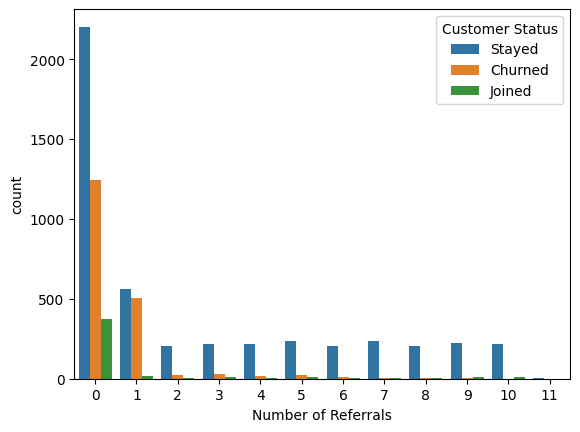

In [ ]:
sns.countplot(data=df, x='Number of Referrals', hue='Customer Status')